In [8]:
from scipy.stats import fisher_exact
from scipy.stats import combine_pvalues
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [4]:
df = pd.read_csv('results/results_df.csv')

In [5]:
# Conservation P-value
pvals = df['RRHO_P'].dropna().tolist()

statistic, global_pval = combine_pvalues(pvals, method='fisher')
print(f"Global Conservation P-value: {global_pval:.2e}")

Global Conservation P-value: 2.22e-07


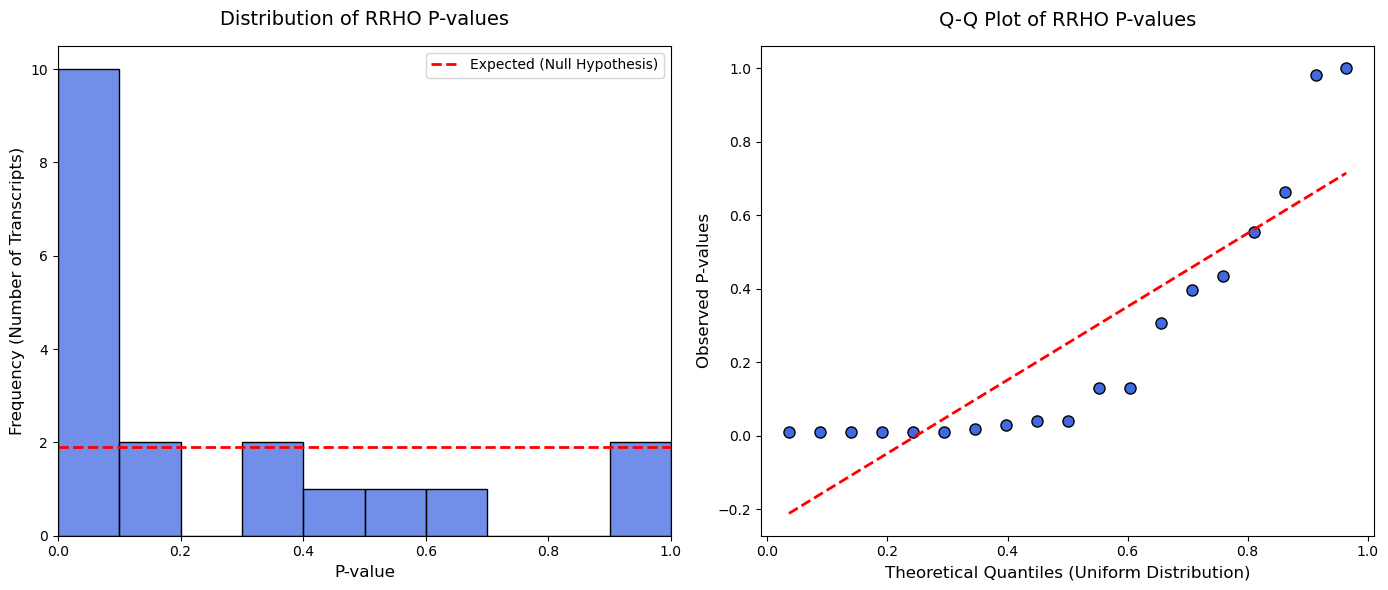

In [9]:
pvals = df['RRHO_P'].dropna().values
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================
# Plot 1: Histogram of P-values
# ==========================================
sns.histplot(pvals, bins=10, binrange=(0, 1), color='royalblue', 
             edgecolor='black', ax=axes[0])

# Set Null Hypothesis (Uniform Distribution)
expected_count = len(pvals) / 10 
axes[0].axhline(expected_count, color='red', linestyle='--', linewidth=2, 
                label='Expected (Null Hypothesis)')

axes[0].set_title('Distribution of RRHO P-values', fontsize=14, pad=15)
axes[0].set_xlabel('P-value', fontsize=12)
axes[0].set_ylabel('Frequency (Number of Transcripts)', fontsize=12)
axes[0].set_xlim(0, 1)
axes[0].legend()

# ==========================================
# Plot 2: Q-Q Plot (Expected vs. Observed)
# ==========================================
# Set Null Hypothesis (Uniform Distribution)
stats.probplot(pvals, dist="uniform", plot=axes[1])

# Customize the Q-Q plot appearance
axes[1].get_lines()[0].set_marker('o')
axes[1].get_lines()[0].set_markerfacecolor('royalblue')
axes[1].get_lines()[0].set_markeredgecolor('black')
axes[1].get_lines()[0].set_markersize(8)
axes[1].get_lines()[1].set_color('red') # The diagonal line
axes[1].get_lines()[1].set_linewidth(2)
axes[1].get_lines()[1].set_linestyle('--')

axes[1].set_title('Q-Q Plot of RRHO P-values', fontsize=14, pad=15)
axes[1].set_xlabel('Theoretical Quantiles (Uniform Distribution)', fontsize=12)
axes[1].set_ylabel('Observed P-values', fontsize=12)

#Adjust and Save
plt.tight_layout()
plt.savefig('pvalue_distribution.png', dpi=300)
plt.show()